# Notebook 02 — Feature Engineering

**Objetivo:** preparar el dataset final para los modelos de Data Mining.  
**Input:** `datasets/processed/logs.csv`  
**Output:** `datasets/processed/features.csv` (dataset listo para ML)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

INPUT  = Path('../datasets/processed/logs.csv')
OUTPUT = Path('../datasets/processed/features.csv')
FIG_DIR = Path('../docs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
df = pd.read_csv(INPUT, parse_dates=['timestamp_dt'])
print(f'Dataset cargado: {df.shape}')
df.head(2)

Dataset cargado: (22844, 46)


/var/folders/84/jv3ccy1s69b2czx0_2_bnz080000gn/T/ipykernel_60720/1052433844.py:1: DtypeWarning: Columns (2,12,14,19,20,23,24,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(INPUT, parse_dates=['timestamp_dt'])


,timestamp_dt,log_type,message,@version,severity,host,log,input,source_type,ecs,...,event_type,ip,method,timestamp,hour,day_of_week,is_weekend,event_count_window,error_count_window,failed_login_count
0,2026-05-06 23:28:29.806000+00:00,error,"2026/05/06 23:28:08 [emerg] 1#1: duplicate ""lo...",1.0,error,{'name': '148e72878c55'},"{'offset': 0, 'file': {'path': '/logs/nginx/er...",{'type': 'filestream'},nginx,{'version': '8.0.0'},...,NaN,NaN,NaN,NaN,23,2,0,1.0,0.0,0.0
1,2026-05-07 00:11:12.781000+00:00,error,"2026/05/07 00:11:09 [emerg] 1#1: duplicate ""lo...",1.0,error,{'name': '148e72878c55'},"{'offset': 99, 'file': {'path': '/logs/nginx/e...",{'type': 'filestream'},nginx,{'version': '8.0.0'},...,NaN,NaN,NaN,NaN,0,3,0,1.0,0.0,0.0


## 1. Selección de features

In [3]:
# Features a incluir en el modelo
NUMERIC_FEATURES = [
    'status_code',
    'response_time_ms',
    'bytes_sent',
    'log_length',
    'event_count_window',
    'error_count_window',
    'failed_login_count',
    'is_error',
    'is_server_error',
    'hour',
    'day_of_week',
    'is_weekend',
]

CATEGORICAL_FEATURES = [
    'source_type',   # nginx / app
    'severity',      # info / warning / error / critical
    'request_method' # GET / POST
]

# Filtrar solo las que existen en el dataset
num_cols  = [c for c in NUMERIC_FEATURES if c in df.columns]
cat_cols  = [c for c in CATEGORICAL_FEATURES if c in df.columns]
all_feats = num_cols + cat_cols

print(f'Features numéricas ({len(num_cols)}): {num_cols}')
print(f'Features categóricas ({len(cat_cols)}): {cat_cols}')

Features numéricas (12): ['status_code', 'response_time_ms', 'bytes_sent', 'log_length', 'event_count_window', 'error_count_window', 'failed_login_count', 'is_error', 'is_server_error', 'hour', 'day_of_week', 'is_weekend']
Features categóricas (3): ['source_type', 'severity', 'request_method']


## 2. Limpieza y valores faltantes

In [4]:
feat_df = df[all_feats + (['label'] if 'label' in df.columns else [])].copy()

# Numéricas: rellenar con 0
feat_df[num_cols] = feat_df[num_cols].fillna(0)

# Categóricas: rellenar con 'unknown'
feat_df[cat_cols] = feat_df[cat_cols].fillna('unknown')

print('Nulos restantes:', feat_df.isnull().sum().sum())
feat_df.describe().round(2)

Nulos restantes: 4


,status_code,response_time_ms,bytes_sent,log_length,event_count_window,error_count_window,failed_login_count,is_error,is_server_error,hour,day_of_week,is_weekend
count,22844.00,22844.00,22844.00,22844.00,22844.00,22844.00,22844.00,22844.00,22844.00,22844.00,22844.00,22844.0
mean,263.74,392.27,3186.84,6.88,6409.73,1454.91,319.98,0.25,0.06,0.00,3.00,0.0
std,107.89,1459.61,2663.59,48.57,3597.37,740.94,166.91,0.43,0.24,0.15,0.01,0.0
min,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,2.00,0.0
25%,200.00,37.00,256.00,0.00,2627.75,766.75,173.00,0.00,0.00,0.00,3.00,0.0
50%,200.00,121.00,2866.00,0.00,8143.50,1853.00,364.00,0.00,0.00,0.00,3.00,0.0
75%,304.00,217.00,5551.25,0.00,9655.00,2082.00,462.00,0.00,0.00,0.00,3.00,0.0
max,503.00,11957.00,8192.00,424.00,9864.00,2285.00,561.00,1.00,1.00,23.00,3.00,0.0


## 3. Encoding de variables categóricas

In [5]:
# Label encoding para variables ordinales (severity)
severity_order = {'info': 0, 'warning': 1, 'error': 2, 'critical': 3, 'unknown': -1}
if 'severity' in feat_df.columns:
    feat_df['severity_enc'] = feat_df['severity'].map(severity_order).fillna(-1).astype(int)
    feat_df = feat_df.drop(columns=['severity'])
    num_cols.append('severity_enc')

# One-hot encoding para el resto
remaining_cat = [c for c in cat_cols if c in feat_df.columns and c != 'severity']
if remaining_cat:
    feat_df = pd.get_dummies(feat_df, columns=remaining_cat, drop_first=True)

print(f'Shape después de encoding: {feat_df.shape}')
feat_df.head(2)

Shape después de encoding: (22844, 19)


,status_code,response_time_ms,bytes_sent,log_length,event_count_window,error_count_window,failed_login_count,is_error,is_server_error,hour,day_of_week,is_weekend,label,severity_enc,source_type_nginx,request_method_POST,request_method_PUT,request_method_SYSTEM,request_method_unknown
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,23,2,0,NaN,2,True,False,False,False,True
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0,3,0,NaN,2,True,False,False,False,True


## 4. Separar features del label

In [6]:
label_col = 'label'
if label_col in feat_df.columns:
    y = feat_df[label_col].copy()
    X = feat_df.drop(columns=[label_col])
    print(f'X: {X.shape}  |  y: {y.shape}')
    print('\nDistribución de y:')
    print(y.value_counts())
else:
    X = feat_df.copy()
    y = None
    print('Sin columna label (modo no supervisado puro)')

X: (22844, 18)  |  y: (22844,)

Distribución de y:
label
normal     16699
anomaly     6141
Name: count, dtype: int64


## 5. Escalado (StandardScaler)

In [7]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

print('Media (primeras features):')
print(X_scaled.mean().head(6).round(6))
print('\nDesviación estándar (primeras features):')
print(X_scaled.std().head(6).round(4))

Media (primeras features):
status_code           0.0
response_time_ms     -0.0
bytes_sent            0.0
log_length            0.0
event_count_window    0.0
error_count_window   -0.0
dtype: float64

Desviación estándar (primeras features):
status_code           1.0
response_time_ms      1.0
bytes_sent            1.0
log_length            1.0
event_count_window    1.0
error_count_window    1.0
dtype: float64


## 6. Visualización PCA 2D — separabilidad de clases

Varianza explicada: PC1=23.3%, PC2=17.7%
Total: 41.0%


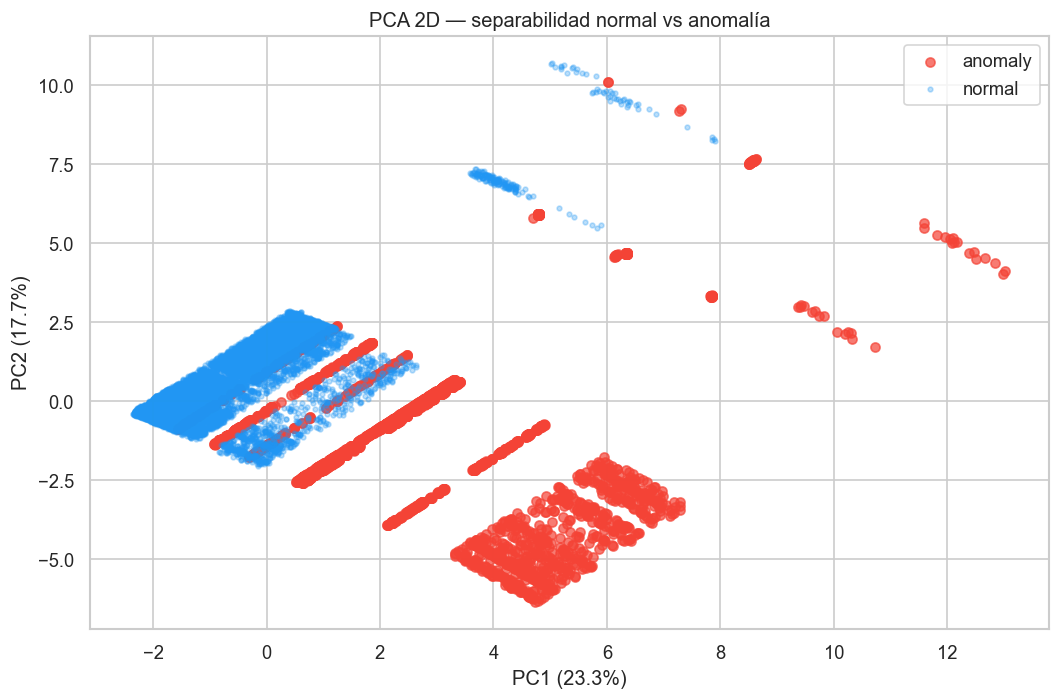

In [8]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
if y is not None:
    pca_df['label'] = y.values

print(f'Varianza explicada: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}')
print(f'Total: {sum(pca.explained_variance_ratio_):.1%}')

fig, ax = plt.subplots(figsize=(9, 6))
if 'label' in pca_df.columns:
    for label, grp in pca_df.groupby('label'):
        color = '#F44336' if label != 'normal' else '#2196F3'
        alpha = 0.7 if label != 'normal' else 0.3
        size = 30 if label != 'normal' else 8
        ax.scatter(grp['PC1'], grp['PC2'],
                   label=label, alpha=alpha, s=size, color=color)
else:
    ax.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.4, s=8)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA 2D — separabilidad normal vs anomalía')
if 'label' in pca_df.columns:
    ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'pca_2d.png', bbox_inches='tight')
plt.show()

## 7. Guardar dataset final

In [9]:
# Guardar X escalado + label
save_df = X_scaled.copy()
if y is not None:
    save_df['label'] = y.values

save_df.to_csv(OUTPUT, index=False)
print(f'Dataset guardado: {OUTPUT}')
print(f'Shape: {save_df.shape}')
print(f'Features del modelo: {list(X_scaled.columns)}')

Dataset guardado: ../datasets/processed/features.csv
Shape: (22844, 19)
Features del modelo: ['status_code', 'response_time_ms', 'bytes_sent', 'log_length', 'event_count_window', 'error_count_window', 'failed_login_count', 'is_error', 'is_server_error', 'hour', 'day_of_week', 'is_weekend', 'severity_enc', 'source_type_nginx', 'request_method_POST', 'request_method_PUT', 'request_method_SYSTEM', 'request_method_unknown']
